In [1]:
import pandas as pd
from pipeline import create_X_y_df
import numpy as np

In [2]:
import pandas as pd
from pipeline import create_X_y_df
import numpy as np

In [2]:
df_full = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [3]:
df = df_full.copy()

In [4]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [5]:
import datetime

df_X["today"] = df_X["date"].max()

In [8]:
df_X["member_since"] = df_X["today"] - df_X["registration"]

In [9]:
df_X["member_since"] = df_X["member_since"].dt.days

In [10]:
df_X.head()

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,...,userAgent,method,length,song,artist,time,registration,date,today,member_since
1,200,F,Vianney,paid,Miller,1563081,1538352002000,Logged In,NextSong,20836,...,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,238.39302,MiÃÂ©ntele,Los Bunkers,2018-10-01 00:00:02,2018-09-21 03:25:18,2018-10-01 00:00:02,2018-11-05,44
448,200,F,Vianney,paid,Miller,1563081,1538352240000,Logged In,NextSong,20836,...,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,263.88853,Animal,Miike Snow,2018-10-01 00:04:00,2018-09-21 03:25:18,2018-10-01 00:04:00,2018-11-05,44
945,200,F,Vianney,paid,Miller,1563081,1538352503000,Logged In,NextSong,20836,...,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,273.47546,Mi Corazon Continuara,Lorena,2018-10-01 00:08:23,2018-09-21 03:25:18,2018-10-01 00:08:23,2018-11-05,44
1509,200,F,Vianney,paid,Miller,1563081,1538352776000,Logged In,NextSong,20836,...,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,284.86485,The Real Slim Shady,Eminem,2018-10-01 00:12:56,2018-09-21 03:25:18,2018-10-01 00:12:56,2018-11-05,44
2066,200,F,Vianney,paid,Miller,1563081,1538353060000,Logged In,NextSong,20836,...,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,304.45669,The People In My Peephole,Claw Hammer,2018-10-01 00:17:40,2018-09-21 03:25:18,2018-10-01 00:17:40,2018-11-05,44


In [23]:
df_a = df_X[["userId", "member_since"]].drop_duplicates()

In [25]:
df_b = df_a.merge(df_y, on = "userId")

In [26]:
df_b

,userId,member_since,Cancellation Confirmation
0,1563081,44,0
1,1697168,57,0
2,1714398,46,0
3,1010522,43,0
4,1475659,55,0
...,...,...,...
15428,1004668,157,0
15429,1306591,47,0
15430,1910265,37,0
15431,1662561,76,0


In [27]:
import seaborn as sns

<Axes: xlabel='Cancellation Confirmation', ylabel='member_since'>

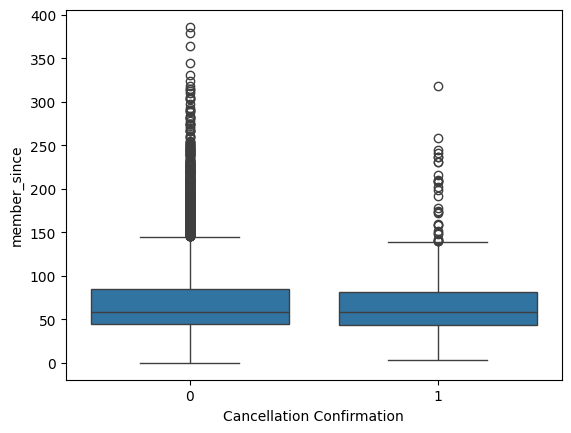

In [28]:
sns.boxplot(df_b, x = "Cancellation Confirmation", y = "member_since")

In [31]:
df_X["last_activity"] = df_X.groupby(["userId"])["date"].transform("max")

In [33]:
df_X["time_delta_no_activity"] = df_X["today"] - df_X["last_activity"]

In [35]:
df_X["time_delta_no_activity"] = df_X["time_delta_no_activity"].dt.days

In [39]:
df_c = df_X[["userId", "time_delta_no_activity"]].drop_duplicates()

In [41]:
df_d = df_c.merge(df_y, on = "userId")

In [43]:
df_d.head()

,userId,time_delta_no_activity,Cancellation Confirmation
0,1563081,1,0
1,1697168,0,0
2,1714398,1,0
3,1010522,0,0
4,1475659,2,0


<Axes: xlabel='Cancellation Confirmation', ylabel='time_delta_no_activity'>

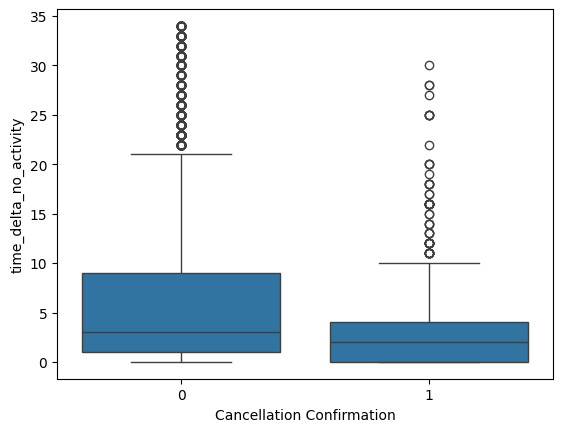

In [44]:
sns.boxplot(df_d, x = "Cancellation Confirmation", y = "time_delta_no_activity")